                    phrase  count
20  brutalist architecture     31
1         exposed concrete     20
11          concrete walls     11
0             raw concrete     10
14      concrete structure      4
15          concrete shell      4
21      brutalist building      2
3        monolithic volume      2
27             curved wall      1
29              solid void      1
13          concrete frame      1
12           concrete wall      1


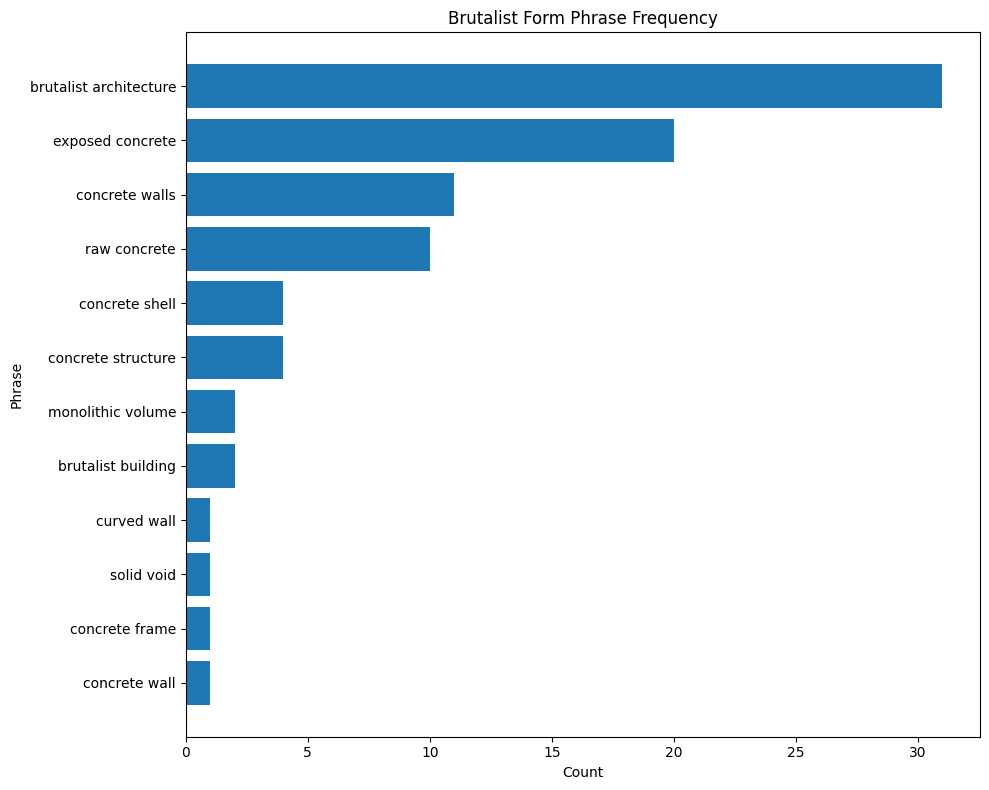

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# 1. 读取 CSV
df = pd.read_csv(r"C:\Users\LZT\Downloads\brutalism_dataset_200\brutalism_architecture_dataset.csv")

# 2. 取 form_text
texts = df["form_text"].dropna().astype(str).tolist()

# 3. 文本清洗
cleaned_texts = []
for text in texts:
    text = text.lower()
    text = re.sub(r"[^a-z\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    cleaned_texts.append(text)

# 4. 定义你关心的建筑形态短语
target_phrases = [
    "raw concrete",
    "exposed concrete",
    "board marked concrete",
    "monolithic volume",
    "monolithic form",
    "monolithic mass",
    "sculptural form",
    "sculptural volume",
    "angular form",
    "angular facade",
    "geometric form",
    "concrete walls",
    "concrete wall",
    "concrete frame",
    "concrete structure",
    "concrete shell",
    "ribbed concrete",
    "textured concrete",
    "monumental form",
    "monumental volume",
    "brutalist architecture",
    "brutalist building",
    "heavy massing",
    "stepped form",
    "layered facade",
    "perforated facade",
    "rectilinear form",
    "curved wall",
    "deep openings",
    "solid void",
    "open plan",
    "cantilevered volume"
]

# 5. 统计短语频率
results = []
all_text = " ".join(cleaned_texts)

for phrase in target_phrases:
    pattern = r"\b" + re.escape(phrase) + r"\b"
    count = len(re.findall(pattern, all_text))
    results.append({"phrase": phrase, "count": count})

phrase_df = pd.DataFrame(results)
phrase_df = phrase_df.sort_values(by="count", ascending=False)

# 6. 只保留出现过的短语
phrase_df = phrase_df[phrase_df["count"] > 0]

# 7. 打印结果
print(phrase_df)

# 8. 保存 CSV
phrase_df.to_csv(
    r"C:\Users\LZT\Downloads\brutalism_dataset_200\form_phrases_frequency.csv",
    index=False,
    encoding="utf-8-sig"
)

# 9. 画图
top20 = phrase_df.head(20).sort_values(by="count", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20["phrase"], top20["count"])
plt.title("Brutalist Form Phrase Frequency")
plt.xlabel("Count")
plt.ylabel("Phrase")
plt.tight_layout()

plt.savefig(
    r"C:\Users\LZT\Downloads\brutalism_dataset_200\form_phrases_frequency.png",
    dpi=300
)

plt.show()
